In [2]:
import random
import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel

random.seed(2026)
np.random.seed(2026)
torch.manual_seed(2026)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
train_df = pd.read_csv('/kaggle/input/alchemy-aicc-round-4/train.csv')
test_df = pd.read_csv('/kaggle/input/alchemy-aicc-round-4/test.csv')
cand_df = pd.read_csv('/kaggle/input/alchemy-aicc-round-4/candidates.csv')
candidate_labels = sorted(cand_df['result'].unique().tolist())

print(f'Train: {len(train_df)} rules')
print(f'Test: {len(test_df)} pairs')
print(f'Candidates: {len(candidate_labels)} unique results')

Train: 150 rules
Test: 70 pairs
Candidates: 70 unique results


In [4]:
len(candidate_labels)

70

In [5]:
import torch.nn.functional as F

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device).eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [53]:
def encode_text(text):
    enc = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True
    ).to(device)

    input_ids = enc['input_ids']
    mask = enc['attention_mask']

    emb = model.get_input_embeddings()(input_ids)

    # 🔥 manually remove CLS and SEP
    special_ids = tokenizer.all_special_ids

    special_mask = torch.ones_like(input_ids)

    for sid in special_ids:
        special_mask = special_mask * (input_ids != sid)

    final_mask = mask * special_mask

    pooled = (emb * final_mask.unsqueeze(-1)).sum(dim=1) / final_mask.sum(dim=1).clamp(min=1e-9)

    return pooled

In [68]:
def encode_pair(pair):
    e1 = encode_text(pair['item1'])
    e2 = encode_text(pair['item2'])

    return e1, e2   # (1, 768)

In [74]:
candidate_embs = torch.cat(
    [encode_text(c) for c in candidate_labels],
    dim=0
)  # (C, D)

candidate_embs = F.normalize(candidate_embs, dim=1)

In [127]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

class PairMLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 3, 1024),
            nn.ReLU(),
            nn.Linear(1024, dim)
        )

    def forward(self, e1, e2):
        x = torch.cat([e1, e2, e1-e2], dim=-1)
        return self.net(x)

In [128]:
def contrastive_loss(pred, target):
    return 1 - F.cosine_similarity(pred, target, dim=1).mean()

In [129]:
augmented = []

for pair in train_df.to_dict("records"):
    A = pair["item1"]
    B = pair["item2"]
    Y = pair["result"]

    # forward
    augmented.append((A, B, Y))

    # reverse
    augmented.append((B, A, Y))

In [130]:
import matplotlib.pyplot as plt

model_mlp = PairMLP(dim=768).to(device)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-4)

losses = []

for epoch in range(3):
    epoch_loss = 0.0

    for A, B, Y in tqdm(augmented):

        e1 = encode_text(A)
        e2 = encode_text(B)
        target = encode_text(Y)

        pred = model_mlp(e1, e2)
        loss = contrastive_loss(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        losses.append(loss.item())

    print(f"Epoch {epoch+1}, avg loss: {epoch_loss / len(augmented):.4f}")

100%|██████████| 300/300 [00:01<00:00, 163.55it/s]


Epoch 1, avg loss: 0.4420


100%|██████████| 300/300 [00:01<00:00, 168.11it/s]


Epoch 2, avg loss: 0.3778


100%|██████████| 300/300 [00:01<00:00, 175.37it/s]

Epoch 3, avg loss: 0.3455


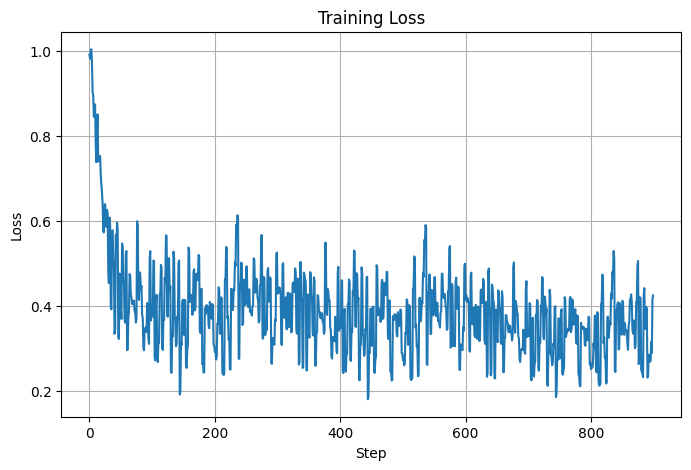

In [131]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [132]:
context_embs = []

for i in range(len(test_df)):
    pair = test_df.iloc[i]

    e1 = encode_text(pair["item1"])
    e2 = encode_text(pair["item2"])

    pred_emb = model_mlp(e1, e2)

    context_embs.append(pred_emb)

context_embs = torch.cat(context_embs, dim=0)
context_embs = F.normalize(context_embs, dim=1)

In [133]:
context_embs = torch.nn.functional.normalize(context_embs, dim=1)
candidate_embs = torch.nn.functional.normalize(candidate_embs, dim=1)

In [134]:
from scipy.optimize import linear_sum_assignment

sim_matrix = context_embs @ candidate_embs.T   # (N, C)

cost = -sim_matrix.detach().cpu().numpy()

row_i, col_i = linear_sum_assignment(cost)

In [135]:
col_i

array([43, 39, 32, 69, 61, 51, 35, 27, 22, 50, 29, 47, 24, 37, 48,  9, 42,
       28,  8, 52, 20,  1, 65, 33, 57, 17, 16, 49, 63,  7, 60, 36, 13,  3,
       67, 23, 53, 34, 15, 55, 64, 56, 30, 40, 68, 31, 62, 21,  4, 54, 26,
        6, 11,  2, 38, 25, 46, 45, 10,  0, 41, 58, 14, 44, 19,  5, 18, 66,
       59, 12])

# Submission

In [101]:
N, C = sim_matrix.shape

used_candidates = set()
predictions = [None] * N

flat_indices = torch.argsort(sim_matrix.flatten(), descending=True)

for idx in flat_indices:
    i = idx.item() // C   # context index
    j = idx.item() % C    # candidate index

    if predictions[i] is not None:
        continue

    if j in used_candidates:
        continue

    predictions[i] = candidate_labels[j]
    used_candidates.add(j)

    if len(used_candidates) == C:
        break

In [136]:
predictions = [None] * len(test_df)
used_candidates = set()

for r, c in zip(row_i, col_i):
    predictions[r] = candidate_labels[c]
    used_candidates.add(c)

In [137]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'result': predictions
})

submission.to_csv('submission.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(submission.head())

Submission shape: (70, 2)
   Id   result
0   0   rocket
1   1   potion
2   2     milk
3   3  whiskey
4   4    tower
